<a href="https://colab.research.google.com/github/keyraharriee/Project-AI-Computer-vision/blob/main/game.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import IPython

matrix_code = """
<canvas id="matrixCanvas" style="background: black; width: 100%; height: 400px;"></canvas>
<script>
const canvas = document.getElementById('matrixCanvas');
const ctx = canvas.getContext('2d');

// Set saiz canvas
canvas.width = canvas.offsetWidth;
canvas.height = canvas.offsetHeight;

const katakana = 'ｱｲｳｴｵｶｷｸｹｺｻｼｽｾｿﾀﾁﾂﾃﾄﾅﾆﾇﾈﾉﾊﾋﾌﾍﾎﾏﾐﾑﾒﾓﾔﾕﾖﾗﾘﾙﾚﾛﾜﾝ1234567890ABCDEFGHIJKLMNOPQRSTUVWXYZ';
const alphabet = katakana.split('');

const fontSize = 16;
const columns = canvas.width / fontSize;

const rainDrops = [];

for( let x = 0; x < columns; x++ ) {
    rainDrops[x] = 1;
}

const draw = () => {
    ctx.fillStyle = 'rgba(0, 0, 0, 0.05)';
    ctx.fillRect(0, 0, canvas.width, canvas.height);

    ctx.fillStyle = '#0F0'; // Warna Hijau Matrix
    ctx.font = fontSize + 'px monospace';

    for(let i = 0; i < rainDrops.length; i++) {
        const text = alphabet[Math.floor(Math.random() * alphabet.length)];
        ctx.fillText(text, i*fontSize, rainDrops[i]*fontSize);

        if(rainDrops[i]*fontSize > canvas.height && Math.random() > 0.975){
            rainDrops[i] = 0;
        }
        rainDrops[i]++;
    }
};

setInterval(draw, 30);
</script>
"""

# Paparkan animasi dalam Colab
IPython.display.HTML(matrix_code)

In [10]:
# Install library jika belum ada
!pip install textblob -q

import ipywidgets as widgets
from IPython.display import display, clear_output
from textblob import TextBlob
import matplotlib.pyplot as plt

# Fungsi untuk analisis sentimen
def analisis_sentimen(teks):
    analisis = TextBlob(teks)
    score = analisis.sentiment.polarity # Skor dari -1 (negatif) hingga 1 (positif)

    # Plot Grafik
    fig, ax = plt.subplots(figsize=(6, 2))
    warna = 'green' if score >= 0 else 'red'
    ax.barh(['Sentimen'], [score], color=warna, edgecolor='black')
    ax.set_xlim(-1, 1)
    ax.axvline(0, color='gray', linestyle='--')
    plt.title(f"Skor: {score:.2f} ({'Positif' if score > 0 else 'Negatif' if score < 0 else 'Neutral'})")
    plt.show()

# Komponen UI Interaktif Colab
input_teks = widgets.Textarea(
    value='Google Colab is absolutely amazing and fun to use!',
    placeholder='Taip sesuatu dalam Bahasa Inggeris...',
    description='Ayat:',
    layout=widgets.Layout(width='80%', height='80px')
)

output = widgets.Output()

def on_change(change):
    with output:
        clear_output(wait=True)
        analisis_sentimen(change['new'])

input_teks.observe(on_change, names='value')

# Paparkan UI
display(widgets.HTML("<h3>🔮 Pengesan Emosi Teks Interaktif</h3>"))
display(input_teks, output)

# Run analisis pertama kali secara automatik
with output:
    analisis_sentimen(input_teks.value)

HTML(value='<h3>🔮 Pengesan Emosi Teks Interaktif</h3>')

Textarea(value='Google Colab is absolutely amazing and fun to use!', description='Ayat:', layout=Layout(height…

Output()

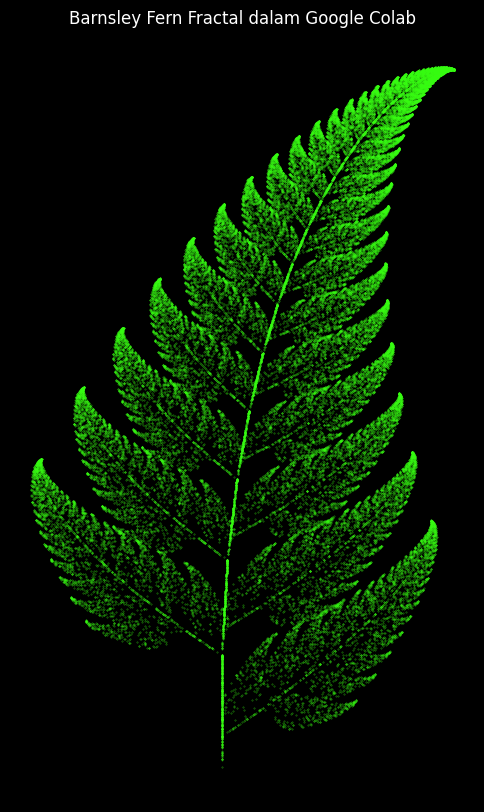

In [3]:
import matplotlib.pyplot as plt
import random

# Koordinat permulaan
x, y = [0], [0]

# Generasi titik berdasarkan kebarangkalian matematik
for i in range(50000):
    r = random.uniform(0, 100)
    if r < 1:
        next_x = 0
        next_y = 0.16 * y[-1]
    elif r < 86:
        next_x = 0.85 * x[-1] + 0.04 * y[-1]
        next_y = -0.04 * x[-1] + 0.85 * y[-1] + 1.6
    elif r < 93:
        next_x = 0.2 * x[-1] - 0.26 * y[-1]
        next_y = 0.23 * x[-1] + 0.22 * y[-1] + 1.6
    else:
        next_x = -0.15 * x[-1] + 0.28 * y[-1]
        next_y = 0.26 * x[-1] + 0.24 * y[-1] + 0.44

    x.append(next_x)
    y.append(next_y)

# Set up paparan grafik di Colab
plt.figure(figsize=(6, 10), facecolor='black')
ax = plt.axes()
ax.set_facecolor("black")

# Plot daun dengan warna hijau neon
plt.scatter(x, y, s=0.1, c='#39FF14', alpha=0.6)
plt.axis('off')
plt.title("Barnsley Fern Fractal dalam Google Colab", color='white', fontsize=12)
plt.show()

In [8]:
import IPython
from IPython.display import HTML

# Kod HTML, CSS, dan JavaScript untuk Game Ular
snake_game_code = """
<div style="text-align: center; font-family: 'Courier New', Courier, monospace; background-color: #111; padding: 20px; border-radius: 10px; width: 450px; margin: auto; color: white;">
    <h2>🐍 SNAKE GAME 🐍</h2>
    <div style="font-size: 18px; margin-bottom: 10px;">Skor: <span id="scoreDisplay">0</span></div>
    <canvas id="gameCanvas" width="400" height="400" style="border: 4px solid #333; background-color: #000;"></canvas>
    <p style="color: #888; font-size: 12px; margin-top: 10px;">Gunakan butang panah (Arrow Keys) pada keyboard untuk bergerak.</p>
    <button id="restartBtn" style="padding: 8px 15px; font-weight: bold; background-color: #4CAF50; color: white; border: none; border-radius: 5px; cursor: pointer; display: none;">Main Semula</button>
</div>

<script>
const canvas = document.getElementById("gameCanvas");
const ctx = canvas.getContext("2d");
const scoreDisplay = document.getElementById("scoreDisplay");
const restartBtn = document.getElementById("restartBtn");

const gridSize = 20;
const tileCount = canvas.width / gridSize;

let snake = [{x: 10, y: 10}];
let food = {x: 5, y: 5};
let dx = 1;
let dy = 0;
let score = 0;
let gameInterval;
let gameSpeed = 100; // Milisaat (Makin kecil, makin laju)

// Fungsi memulakan game
function startGame() {
    snake = [{x: 10, y: 10}];
    generateFood();
    dx = 1;
    dy = 0;
    score = 0;
    scoreDisplay.innerText = score;
    restartBtn.style.display = "none";
    clearInterval(gameInterval);
    gameInterval = setInterval(updateGame, gameSpeed);
}

// Logik utama game (diulang setiap 100ms)
function updateGame() {
    moveSnake();

    if (checkGameOver()) {
        clearInterval(gameInterval);
        ctx.fillStyle = "rgba(0, 0, 0, 0.75)";
        ctx.fillRect(0, 0, canvas.width, canvas.height);
        ctx.fillStyle = "red";
        ctx.font = "30px Courier New";
        ctx.fillText("GAME OVER", canvas.width/2 - 80, canvas.height/2);
        restartBtn.style.display = "inline-block";
        return;
    }

    checkFoodCollision();
    draw();
}

// Pergerakan ular
function moveSnake() {
    const head = {x: snake[0].x + dx, y: snake[0].y + dy};
    snake.unshift(head); // Tambah kepala bahu di depan
    snake.pop(); // Buang ekor belakang (kecuali jika makan makanan)
}

// Tukar arah menggunakan arrow keys
window.addEventListener("keydown", e => {
    // Elakkan page daripada skrol atas bawah apabila tekan panah
    if(["ArrowUp", "ArrowDown", "ArrowLeft", "ArrowRight"].includes(e.key)) {
        e.preventDefault();
    }

    switch(e.key) {
        case "ArrowUp":    if (dy === 0) { dx = 0; dy = -1; } break;
        case "ArrowDown":  if (dy === 0) { dx = 0; dy = 1; } break;
        case "ArrowLeft":  if (dx === 0) { dx = -1; dy = 0; } break;
        case "ArrowRight": if (dx === 0) { dx = 1; dy = 0; } break;
    }
});

// Semak pelanggaran dinding atau diri sendiri
function checkGameOver() {
    const head = snake[0];

    // Pelanggaran dinding
    if (head.x < 0 || head.x >= tileCount || head.y < 0 || head.y >= tileCount) {
        return true;
    }

    // Pelanggaran badan sendiri
    for (let i = 1; i < snake.length; i++) {
        if (head.x === snake[i].x && head.y === snake[i].y) {
            return true;
        }
    }
    return false;
}

// Semak jika ular makan makanan
function checkFoodCollision() {
    if (snake[0].x === food.x && snake[0].y === food.y) {
        score += 10;
        scoreDisplay.innerText = score;

        // Tambah panjang ular dengan tidak membuang ekor pada pusingan ini
        const tail = { ...snake[snake.length - 1] };
        snake.push(tail);

        generateFood();
    }
}

// Letak makanan di posisi rawak
function generateFood() {
    food.x = Math.floor(Math.random() * tileCount);
    food.y = Math.floor(Math.random() * tileCount);

    // Pastikan makanan tidak muncul di atas badan ular
    snake.forEach(part => {
        if (part.x === food.x && part.y === food.y) {
            generateFood();
        }
    });
}

// Lukis grafik pada Canvas
function draw() {
    // Bersihkan canvas
    ctx.fillStyle = "#000";
    ctx.fillRect(0, 0, canvas.width, canvas.height);

    // Lukis Ular (Kepala warna hijau terang, badan warna hijau biasa)
    snake.forEach((part, index) => {
        ctx.fillStyle = index === 0 ? "#00FF00" : "#4CAF50";
        ctx.strokeStyle = "#000";
        ctx.fillRect(part.x * gridSize, part.y * gridSize, gridSize - 2, gridSize - 2);
        ctx.strokeRect(part.x * gridSize, part.y * gridSize, gridSize - 2, gridSize - 2);
    });

    // Lukis Makanan (Warna Merah)
    ctx.fillStyle = "#FF5722";
    ctx.fillRect(food.x * gridSize, food.y * gridSize, gridSize - 2, gridSize - 2);
}

restartBtn.addEventListener("click", startGame);

// Mula game buat kali pertama
startGame();
</script>
"""

# Paparkan game di dalam output Colab
HTML(snake_game_code)

In [9]:
import IPython
from IPython.display import HTML

# Kod integrasi HTML, CSS, dan JavaScript untuk Papan Catur Interaktif
chess_game_code = """
<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/chessboard-js/1.0.0/chessboard-1.0.0.min.css">
<script src="https://cdnjs.cloudflare.com/ajax/libs/jquery/3.6.0/jquery.min.js"></script>
<script src="https://cdnjs.cloudflare.com/ajax/libs/chess.js/0.10.3/chess.min.js"></script>
<script src="https://cdnjs.cloudflare.com/ajax/libs/chessboard-js/1.0.0/chessboard-1.0.0.min.js"></script>

<div style="text-align: center; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; background-color: #222; padding: 25px; border-radius: 12px; width: 450px; margin: auto; color: white; box-shadow: 0px 4px 15px rgba(0,0,0,0.5);">
    <h2 style="margin-top: 0; color: #f0d9b5;">♟️ COLAB CHESS GAME ♟️</h2>
    <div style="margin-bottom: 15px; font-size: 14px;">
        <span id="status" style="font-weight: bold; color: #ffb74d;">Giliran Anda (Putih)</span>
    </div>

    <div id="myBoard" style="width: 400px; margin: auto; border: 2px solid #555;"></div>

    <div style="margin-top: 15px;">
        <button id="startBtn" style="padding: 8px 15px; font-weight: bold; background-color: #f0d9b5; color: #333; border: none; border-radius: 4px; cursor: pointer; margin-right: 5px;">Reset Game</button>
        <button id="undoBtn" style="padding: 8px 15px; font-weight: bold; background-color: #555; color: white; border: none; border-radius: 4px; cursor: pointer;">Undo</button>
    </div>
</div>

<script>
var board = null
var game = new Chess()
var $status = $('#status')

function onDragStart (source, piece, position, orientation) {
  // Jangan benarkan gerakkan buah hitam (kerana hitam adalah AI) atau jika game dah tamat
  if (game.game_over() || piece.search(/^b/) !== -1) return false
}

function makeRandomMove () {
  var possibleMoves = game.moves()

  // Game tamat
  if (possibleMoves.length === 0) return

  // Logik AI Mudah: Pilih langkah secara rawak
  var randomIdx = Math.floor(Math.random() * possibleMoves.length)
  game.move(possibleMoves[randomIdx])
  board.position(game.fen())
  updateStatus()
}

function onDrop (source, target) {
  // Semak sama ada langkah tersebut sah (legal move)
  var move = game.move({
    from: source,
    to: target,
    promotion: 'q' // Automatik tukar jadi Queen jika sampai hujung
  })

  // Jika langkah tidak sah, pulangkan buah catur ke tempat asal
  if (move === null) return 'snapback'

  updateStatus()

  // Beri masa 500ms sebelum AI (Hitam) buat langkah balas
  window.setTimeout(makeRandomMove, 500)
}

function onSnapEnd () {
  board.position(game.fen())
}

function updateStatus () {
  var status = ''

  var moveColor = 'White'
  if (game.turn() === 'b') {
    moveColor = 'Black'
  }

  // Semak status permainan
  if (game.in_checkmate()) {
    status = 'Game Over, ' + moveColor + ' kena Checkmate.'
  } else if (game.in_draw()) {
    status = 'Game Over, Keputusan Seri (Draw).'
  } else {
    status = 'Giliran: ' + (moveColor === 'White' ? 'Anda (Putih)' : 'AI (Hitam)')
    if (game.in_check()) {
      status += ' - Kena CHECK!'
    }
  }

  $status.html(status)
}

var config = {
  draggable: true,
  position: 'start',
  onDragStart: onDragStart,
  onDrop: onDrop,
  onSnapEnd: onSnapEnd,
  pieceTheme: 'https://chessboardjs.com/img/chesspieces/wikipedia/{piece}.png' // Gambar buah catur standard
}
board = Chessboard('myBoard', config)

updateStatus()

// Fungsi Butang Reset
$('#startBtn').on('click', function() {
    game.reset()
    board.start()
    updateStatus()
})

// Fungsi Butang Undo
$('#undoBtn').on('click', function() {
    game.undo() // Undo langkah AI
    game.undo() // Undo langkah pemain
    board.position(game.fen())
    updateStatus()
})
</script>
"""

# Paparkan catur di dalam output Colab
HTML(chess_game_code)